## Module End Assignment - 5 : Python for Data Analysis
####  Prolect : Social media Engagement Analytics Using Python


 #### ❖	Task 1 — Data Import & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings;
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv(r"F:\PYTHON\DAA51\social_media_engagement_5000.csv")
print(df.shape)
print(df.head())

(5000, 19)
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count   posted_at  \
0     354.0  1157.0            5726             44650  17-12-2022   
1    2606.0  1807.0            5947             80216  02-06-2023   
2     344.0   955.0            6946             44858  07-05-2023   
3    1083.0  1049.0             229             70455  12-02-2023   
4    2735.0  1300.0            4798              6019  23-05-2023   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        F

In [4]:
## Check/convert data types

print(df.dtypes)

user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object


In [5]:
####  Convert date columns to datetime

df['posted_at']=pd.to_datetime(df['posted_at'])
print(df['posted_at'].dtype)
print(df['posted_at'].head())

datetime64[ns]
0   2022-12-17
1   2023-06-02
2   2023-05-07
3   2023-02-12
4   2023-05-23
Name: posted_at, dtype: datetime64[ns]


In [115]:
#### Use NumPy arrays for basic array operations

likes_array=np.array(df['likes'])
print("Likes array:",likes_array[:10])

print("Mean:",np.nanmean(likes_array))
print("Max:",np.nanmax(likes_array))
print("Min:",np.nanmin(likes_array))
print("std:",np.nanstd(likes_array))

Likes array: [ 7011 11750  4862  5350 12682 12535 11703  9611 10105 14106]
Mean: 10105.831897415348
Max: 19998
Min: 10
std: 5703.056654897313


### ❖	Task 2 — Data Cleaning

#### Cleaning Missing Data

######  ■	Detect missing values (isnull(), isna())

In [7]:
print("Missing values:")
print(df.isnull().sum())

print("----------\n ----------")
print(df.isna().sum())

Missing values:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64
----------
 ----------
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


######  ■	Handle using: dropna(), fillna(), median/mode, forward/backward-fill

In [8]:
# Numeric using median
df['age'].fillna(df['age'].median(),inplace=True)
df['likes'].fillna(df['likes'].median(),inplace=True)
df['comments'].fillna(df['comments'].median(),inplace=True)
df['shares'].fillna(df['shares'].median(),inplace=True)

# for categorical using mode

df['gender'].fillna(df['gender'].mode()[0],inplace=True)
df['sentiment'].fillna(df['sentiment'].mode()[0],inplace=True)

print(df.isnull().sum())
print("Shape aftercleaning:",df.shape)

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64
Shape aftercleaning: (5000, 19)


In [9]:
# Forward ,Backward fill

df['age'].fillna(method='ffill',inplace=True)
df['age'].fillna(method='bfill',inplace=True)

df.dropna(inplace=True)
print("Shape aftercleaning:",df.shape)

Shape aftercleaning: (5000, 19)


#### ●	Duplicate Handling

In [10]:
#####  	Identify & remove duplicates

print("Shape Before:",df.shape)
print("Duplicate rows:",df.duplicated().sum())
print("Duplicated post_id:",df.duplicated(subset=['post_id']).sum())

df.drop_duplicates(subset=['post_id'],keep='first',inplace=True)
df.drop_duplicates(inplace=True)

print("Shape aftercleaning:",df.shape)

Shape Before: (5000, 19)
Duplicate rows: 0
Duplicated post_id: 9
Shape aftercleaning: (4991, 19)


#### ●	Data Formatting

In [11]:
#### ■	Fix incorrect data types
print(df.dtypes)

user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
dtype: object


In [12]:
df['age']=df['age'].astype(int)
df['likes']=df['likes'].astype(int)
df['comments']=df['comments'].astype(int)
df['shares']=df['shares'].astype(int)


print(df.dtypes)


user_id                      int64
age                          int64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                        int64
comments                     int64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
dtype: object


In [13]:
#■	Standardize categories (e.g., gender labels)

print("Gender Before:",df['gender'].unique())
print("post_type Before:",df['post_type'].unique())
print("sentiment Before:",df['sentiment'].unique())

df['post_type']=df['post_type'].astype(str).str.capitalize()
df['sentiment']=df['sentiment'].astype(str).str.capitalize()

print("post_type After:",df['post_type'].unique())
print("sentiment After:",df['sentiment'].unique())


print("Shape",df.shape)    
print(df.dtypes)

Gender Before: ['Female' 'Male' 'Other']
post_type Before: ['image' 'reel' 'text' 'video']
sentiment Before: ['negative' 'positive' 'neutral']
post_type After: ['Image' 'Reel' 'Text' 'Video']
sentiment After: ['Negative' 'Positive' 'Neutral']
Shape (4991, 19)
user_id                      int64
age                          int64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                        int64
comments                     int64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
dtype: object


In [14]:
##### ■	Correct unrealistic values in likes, comments, shares

print(df[['likes','comments','shares']].describe())

print((df['likes']<0).sum(),(df['comments']<0).sum(),(df['shares']<0).sum())

              likes     comments       shares
count   4991.000000  4991.000000  4991.000000
mean   10105.831897  1501.511921  1002.897015
std     5703.628075   856.683226   570.842898
min       10.000000     0.000000     0.000000
25%     5224.500000   791.000000   511.000000
50%    10105.000000  1497.000000  1012.000000
75%    14965.000000  2234.500000  1482.500000
max    19998.000000  2999.000000  1999.000000
0 0 0


##### ●	 Feature Cleaning

In [15]:
##  ■	Extract hashtag count

print(df['hashtags'].head())

df['hashtag_count']=df['hashtags'].astype(str).apply(lambda x:0 if x.lower()=='nan' else len(x.split()))

print(df[['hashtags','hashtag_count']].head(10))

#print("Hashtag_Count status:",df['Hashtag_Count'].describe()[['min','max','mean']])

print("\n Hashtag count stats:")
print(df['hashtag_count'].describe())

0    #foodie #travel #love
1                 #fitness
2                  #foodie
3      #music #foodie #fun
4                  #travel
Name: hashtags, dtype: object
                  hashtags  hashtag_count
0    #foodie #travel #love              3
1                 #fitness              1
2                  #foodie              1
3      #music #foodie #fun              3
4                  #travel              1
5                 #fitness              1
6                   #music              1
7  #travel #music #fitness              3
8     #music #fun #fitness              3
9         #lifestyle #love              2

 Hashtag count stats:
count    4991.000000
mean        1.998998
std         0.813094
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: hashtag_count, dtype: float64


In [16]:
df=df.drop(columns=['hashtags','hashtag_count'],errors='ignore')

np.random.seed(42)
df['hashtag_count']=np.random.randint(1,6,size=len(df))

def make_tags(n):
    sample_tags=['#love','#viral','#fyp','#trending','#instagood','#photo','#reels']
    return''.join(np.random.choice(sample_tags,n))

df['hashtags']=df['hashtag_count'].apply(make_tags)


#clean

df['sentiment']=df['sentiment'].astype(str).str.strip().str.capitalize()
valid=['Positive','Negative','Neutral']
df['sentiment']=df['sentiment'].apply(lambda x:x if x in valid else 'Neutral')


print(df[['hashtags','hashtag_count']].head(10))
print("\n Hashcount stats:")
print(df['hashtag_count'].describe())
print(df.shape)
print(df.dtypes)

                                           hashtags  hashtag_count
0               #trending#instagood#instagood#viral              4
1          #trending#trending#photo#instagood#reels              5
2                         #trending#instagood#photo              3
3                #reels#photo#viral#reels#instagood              5
4  #trending#trending#instagood#instagood#instagood              5
5                                        #fyp#reels              2
6                             #trending#reels#photo              3
7                           #trending#fyp#instagood              3
8                        #viral#instagood#instagood              3
9            #fyp#reels#trending#instagood#trending              5

 Hashcount stats:
count    4991.000000
mean        3.008616
std         1.424424
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: hashtag_count, dtype: float64
(4991, 20)
user_id                      

In [18]:
print(df['sentiment'].value_counts())
print("Final:",df.shape)

sentiment
Positive    2508
Neutral     1525
Negative     958
Name: count, dtype: int64
Final: (4991, 20)


### ❖	Task 3 — Data Exploration using Pandas

In [19]:
#### View dataset structure using head(), tail(), shape, and columns

print("Shape:",df.shape)
print("\n Columns:",df.columns.tolist())
print("\n ---- Head -----")
print(df.head())
print("\n ---- Tail -----")
print(df.tail())

Shape: (4991, 20)

 Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'engagement_rate', 'hashtag_count', 'hashtags']

 ---- Head -----
   user_id  age  gender country  post_id post_type post_category  likes  \
0    25795   43  Female  Brazil   496713     Image       fitness   7011   
1    10860   33    Male  Brazil   157326      Reel          food  11750   
2    86820   32  Female      UK   109864      Text          food   4862   
3    64886   51   Other  France   848877      Text       fitness   5350   
4    16265   34   Other      UK   449706     Image       fitness  12682   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0       354    1157            5726             44650 2022-12-17   
1      2606    1807            5947             80216 2023-06-02   
2       344     955       

In [20]:
##### ●	Check data types and info with info() and dtypes.

print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
Index: 4991 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           4991 non-null   int64         
 1   age               4991 non-null   int64         
 2   gender            4991 non-null   object        
 3   country           4991 non-null   object        
 4   post_id           4991 non-null   int64         
 5   post_type         4991 non-null   object        
 6   post_category     4991 non-null   object        
 7   likes             4991 non-null   int64         
 8   comments          4991 non-null   int64         
 9   shares            4991 non-null   int64         
 10  watch_time_sec    4991 non-null   int64         
 11  impression_count  4991 non-null   int64         
 12  posted_at         4991 non-null   datetime64[ns]
 13  follower_count    4991 non-null   int64         
 14  is_verified       4991 non-nu

In [21]:
#### ●	Generate summary statistics using describe().

print(df.describe())
print("\n --- Include All ----")
print(df.describe(include='all').T)

            user_id          age        post_id         likes     comments  \
count   4991.000000  4991.000000    4991.000000   4991.000000  4991.000000   
mean   54547.943699    38.439591  547854.825486  10105.831897  1501.511921   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32281.000000    26.000000  322410.000000   5224.500000   791.000000   
50%    54327.000000    38.000000  547905.000000  10105.000000  1497.000000   
75%    77172.500000    51.000000  771256.500000  14965.000000  2234.500000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   
std    26094.658996    14.686923  260657.341322   5703.628075   856.683226   

            shares  watch_time_sec  impression_count  \
count  4991.000000     4991.000000       4991.000000   
mean   1002.897015     4015.120617      50029.706872   
min       0.000000        0.000000        105.000000   
25%     511.000000     2023.500000      24997.000000   
50%    1012.00000

In [22]:
##### ●	Analyze categorical distributions using value_counts(), unique(), and nunique().

for col in ['gender','country','post_type','device_type','post_category','sentiment','is_verified']:
    if col in df.columns:
         print(f"\n ---- {col}-------")
         print(f"Unique:{df[col].unique()[:5]}")
         print(f"Nunique: {df[col].nunique()}")
         print(df[col].value_counts().head(3))
        


 ---- gender-------
Unique:['Female' 'Male' 'Other']
Nunique: 3
gender
Male      1842
Other     1581
Female    1568
Name: count, dtype: int64

 ---- country-------
Unique:['Brazil' 'UK' 'France' 'Canada' 'Japan']
Nunique: 10
country
India     534
Canada    512
Brazil    504
Name: count, dtype: int64

 ---- post_type-------
Unique:['Image' 'Reel' 'Text' 'Video']
Nunique: 4
post_type
Reel     1281
Image    1244
Text     1243
Name: count, dtype: int64

 ---- device_type-------
Unique:['mobile' 'tablet' 'desktop']
Nunique: 3
device_type
mobile     1681
desktop    1656
tablet     1654
Name: count, dtype: int64

 ---- post_category-------
Unique:['fitness' 'food' 'tech' 'travel' 'fashion']
Nunique: 8
post_category
fitness    674
tech       665
music      634
Name: count, dtype: int64

 ---- sentiment-------
Unique:['Negative' 'Positive' 'Neutral']
Nunique: 3
sentiment
Positive    2508
Neutral     1525
Negative     958
Name: count, dtype: int64

 ---- is_verified-------
Unique:[False  True]


                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.006995  0.020044  0.025699 -0.033286  0.013772   
age              -0.006995  1.000000 -0.013129 -0.036659 -0.007792  0.013386   
post_id           0.020044 -0.013129  1.000000  0.014714 -0.010861  0.001959   
likes             0.025699 -0.036659  0.014714  1.000000 -0.018987  0.004819   
comments         -0.033286 -0.007792 -0.010861 -0.018987  1.000000  0.005410   
shares            0.013772  0.013386  0.001959  0.004819  0.005410  1.000000   
watch_time_sec   -0.016871  0.005189  0.018832  0.007566 -0.017197  0.014394   
impression_count  0.015236  0.014138 -0.007299  0.007205 -0.009278 -0.004695   
follower_count    0.009993 -0.025847 -0.002425 -0.022435 -0.011117 -0.010922   
engagement_rate  -0.004185  0.007949  0.010236  0.093570  0.000057  0.021664   
hashtag_count    -0.022797  0.006678  0.016272 -0.004049  0.002928  0.031394   

                  watch_time_sec  impre

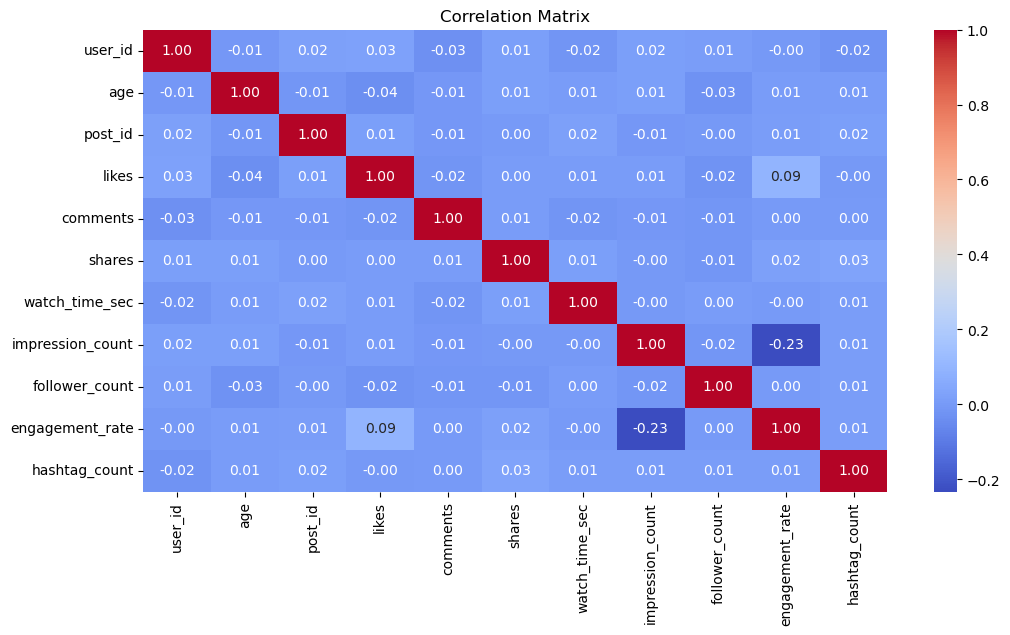

In [91]:
##### ●	Create a correlation matrix for numeric fields.

corr_df=df.select_dtypes(include=['number']).corr()
print(corr_df)

plt.figure(figsize=(12,6))
sns.heatmap(corr_df,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


In [23]:
##### ●	Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

print("Avg likes by post type:")
print(df.groupby('post_type')['likes'].mean().sort_values(ascending=False))

print("\n Avg impressions by country:")
print(df.groupby('country')['impression_count'].mean().sort_values(ascending=False))

print("\n Avg engagement by post_category:")
print(df.groupby('post_category')['engagement_rate'].mean())



Avg likes by post type:
post_type
Video    10187.673753
Image    10103.127010
Text     10099.928399
Reel     10036.050742
Name: likes, dtype: float64

 Avg impressions by country:
country
India        52540.885768
France       51727.673387
USA          51263.872255
UK           51113.342159
Japan        49616.135593
Brazil       49193.174603
UAE          48935.631474
Canada       48656.490234
Germany      48645.110429
Australia    48422.881633
Name: impression_count, dtype: float64

 Avg engagement by post_category:
post_category
education    0.844649
fashion      0.808134
fitness      0.863606
food         1.360471
lifestyle    1.093556
music        0.889566
tech         1.160475
travel       0.703073
Name: engagement_rate, dtype: float64


#### ❖	Task 4 — Data Wrangling 

In [106]:
####   ●Use merge, concat, or join if combining DataFrames.

df1=df[['post_id','post_type','post_category','likes','comments','shares','engagement_rate']].head(100)

df2=df[['post_id','user_id','age','gender','country','follower_count','is_verified']].head(100)

print("DF1 Shape:",df1)
print("DF2 Shape:",df2)
print(df1.head(2))
print(df2.head(2))

print("\n---------------MERGE(on post_id)-------------------")
merged_df=pd.merge(df1,df2,on='post_id',how='inner')
print(f"Merged shape:{merged_df.shape}")
print(merged_df.head(3))

#concat
print("================Concat==================")

df_concat1=df[['likes','comments','shares']].head(5)
df_concat2=df[['watch_time_sec','impression_count']].head(5)
concat_result=pd.concat([df_concat1,df_concat2],axis=1)
print(f"\n CONCATENATION={concat_result.shape}(cols added)")
print(cocat_result.head(3))


DF1 Shape:     post_id post_type post_category  likes  comments  shares  engagement_rate
0    496713     Image       fitness   7011       354    1157         0.190862
1    157326      Reel          food  11750      2606    1807         0.201493
2    109864      Text          food   4862       344     955         0.137345
3    848877      Text       fitness   5350      1083    1049         0.106195
4    449706     Image       fitness  12682      2735    1300         2.777372
..      ...       ...           ...    ...       ...     ...              ...
95   805191     Image       fashion    456       416    1365         0.072143
96   578388     Image          tech    500      2776     425         0.079303
97   789963     Image       fashion  18699      1237     882         0.213983
98   730734      Text          food   3874       847    1837         0.120642
99   984884      Text        travel   4973       669     785         0.114520

[100 rows x 7 columns]
DF2 Shape:     post_id  user_

In [39]:
print(df['hashtags'].head(10).tolist())

df['hashtag_count']=df['hashtags'].astype(str).apply(lambda x:x.count('#'))

print("Corrected hashtag_count:")
print(df['hashtag_count'].describe())
print(df['hashtag_count'].value_counts().head(10))

print("\n sample:)")
print(df[['hashtags','hashtag_count']].head(10))

['#trending#instagood#instagood#viral', '#trending#trending#photo#instagood#reels', '#trending#instagood#photo', '#reels#photo#viral#reels#instagood', '#trending#trending#instagood#instagood#instagood', '#fyp#reels', '#trending#reels#photo', '#trending#fyp#instagood', '#viral#instagood#instagood', '#fyp#reels#trending#instagood#trending']
Corrected hashtag_count:
count    4991.000000
mean        3.008616
std         1.424424
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: hashtag_count, dtype: float64
hashtag_count
5    1020
1    1019
4    1005
3     983
2     964
Name: count, dtype: int64

 sample:)
                                           hashtags  hashtag_count
0               #trending#instagood#instagood#viral              4
1          #trending#trending#photo#instagood#reels              5
2                         #trending#instagood#photo              3
3                #reels#photo#viral#reels#instagood          

In [40]:
#### • Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag_count

# engagement_score 
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
print("engagement_score:")
print(df['engagement_score'].head(10))


# hashtag_count 

print("\nHashtag sample:")
print(df['hashtags'].head(5).tolist())

df['hashtag_count'] = df['hashtags'].astype(str).apply(lambda x: x.count('#'))

print("\nCorrected hashtag_count:")
print(df['hashtag_count'].describe())
print(df['hashtag_count'].value_counts().sort_index())

print("\nVerification:")
print(df[['hashtags','hashtag_count']].head(10))

print(f"\n✅ FINAL SUMMARY")
print(f"engagement_score mean: {df['engagement_score'].mean():.2f}")
print(f"log_engagement_score mean: {df['log_engagement_score'].mean():.2f}")
print(f"hashtag_count mean: {df['hashtag_count'].mean():.2f}, unique: {sorted(df['hashtag_count'].unique())}")


engagement_score:
0     8522
1    16163
2     6161
3     7482
4    16717
5    14424
6    15444
7    10181
8    14381
9    17639
Name: engagement_score, dtype: int64

Log metrics:
   likes  log_likes  engagement_score  log_engagement_score
0   7011   8.855378              8522              9.050524
1  11750   9.371694             16163              9.690542
2   4862   8.489411              6161              8.726157
3   5350   8.585039              7482              8.920389
4  12682   9.448018             16717              9.724241

Hashtag sample:
['#trending#instagood#instagood#viral', '#trending#trending#photo#instagood#reels', '#trending#instagood#photo', '#reels#photo#viral#reels#instagood', '#trending#trending#instagood#instagood#instagood']

Corrected hashtag_count:
count    4991.000000
mean        3.008616
std         1.424424
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: hashtag_count, dtype: float64
hashtag_cou

In [48]:
#### ●	Perform groupby summaries by post_type, country, and sentiment.

print("\n ---- Groupby by Post type-------------")
post_type_summary=df.groupby('post_type').agg({'likes':'mean','comments':'mean',
                    'shares':'mean','engagement_score':'mean','post_id':'count'}).rename(columns={'post_id':'post_count'}).round(2)
print(post_type_summary.sort_values('engagement_score',ascending=False))



 ---- Groupby by Post type-------------
              likes  comments   shares  engagement_score  post_count
post_type                                                           
Video      10187.67   1479.57   997.69          12664.94        1223
Image      10103.13   1524.81  1018.61          12646.55        1244
Text       10099.93   1497.91  1013.04          12610.87        1243
Reel       10036.05   1503.33   982.77          12522.15        1281


In [49]:
print("\n ---- Groupby by Sentiment     ---")
sentiment_summary=df.groupby('sentiment').agg({'likes':'mean','comments':'mean',
                    'shares':'mean','engagement_score':'mean','post_id':'count'}).rename(columns={'post_id':'post_count'}).round(2)
print(sentiment_summary.sort_values('engagement_score',ascending=False))


 ---- Groupby by Sentiment     ---
              likes  comments   shares  engagement_score  post_count
sentiment                                                           
Negative   10208.04   1514.57  1006.06          12728.67         958
Positive   10180.66   1480.32  1005.38          12666.37        2508
Neutral     9918.56   1528.15   996.83          12443.54        1525


In [50]:
print("\n ---- Groupby by Country     ---")
country_summary=df.groupby('country').agg({'likes':'mean','comments':'mean',
                    'shares':'mean','engagement_score':'mean','post_id':'count'}).rename(columns={'post_id':'post_count'}).round(2)
print(country_summary.sort_values('engagement_score',ascending=False))

                           


 ---- Groupby by Country     ---
              likes  comments   shares  engagement_score  post_count
country                                                             
France     10372.86   1478.70  1051.81          12903.37         496
Australia  10294.97   1483.44  1028.43          12806.83         490
UAE        10229.73   1541.19   991.04          12761.96         502
Germany    10124.16   1529.74   973.26          12627.15         489
Canada     10056.56   1547.66   998.06          12602.28         512
Japan      10088.85   1530.43   959.35          12578.64         472
USA        10122.35   1457.96   995.14          12575.45         501
India       9979.62   1494.36  1034.10          12508.08         534
Brazil      9886.68   1490.43  1008.86          12385.97         504
UK          9915.48   1461.59   984.41          12361.47         491


#### ❖	Task 5 — Statistical Analysis 

In [65]:
cols= ['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']

#mean,median,mode,std,varience,percentiles

print("\n.Mean,Median,Std,Varience,Min,Max:")
desc=df[cols].agg(['mean','median','std','var','min','max']).round(2)
print(desc)


#mode
print("\n2.Mode:")
print(df[cols].mode().iloc[0].round(2))

#percentiles
print("\nPercentiles(25%,50%,75%,90%,99%):")
for col in cols:
        print(f"\n ----- {col} --------")
        print(f"Mean:{df[col].mean():.2f}")
        print(f"Median:{df[col].median():.2f}")
        print(f"Mode:{df[col].mode()[0]}")
        print(f"Std dev:{df[col].std():.2f}")
        print(f"Varience:{df[col].var():.2f}")
        print(f"Percentiles:\n{df[col].quantile([0.25,0.5,0.75,0.90,0.99])}")
        print(f"Skewness:{df[col].skew():.2f}")
        print(f"Kurtosis:{df[col].kurtosis():.2f}")


.Mean,Median,Std,Varience,Min,Max:
              likes   comments     shares  watch_time_sec  engagement_rate  \
mean       10105.83    1501.51    1002.90         4015.12             0.96   
median     10105.00    1497.00    1012.00         4034.00             0.25   
std         5703.63     856.68     570.84         2307.05             5.32   
var     32531373.22  733906.15  325861.61      5322494.22            28.33   
min           10.00       0.00       0.00            0.00             0.01   
max        19998.00    2999.00    1999.00         7998.00           191.50   

        follower_count  
mean      3.939047e+05  
median    3.890400e+05  
std       2.308989e+05  
var       5.331428e+10  
min       8.700000e+01  
max       7.995330e+05  

2.Mode:
likes               10105.00
comments             1497.00
shares               1012.00
watch_time_sec        916.00
engagement_rate         0.01
follower_count     497502.00
Name: 0, dtype: float64

Percentiles(25%,50%,75%,90%,99%):


#### ❖	Task 6 — Data Visualization 

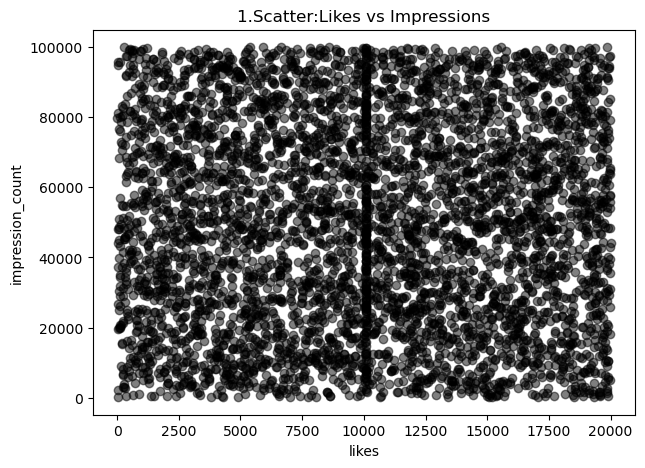

In [73]:
####●	Matplotlib

## ○	Scatter: likes vs impressions

plt.figure(figsize=(7,5))
plt.scatter(df['likes'],df['impression_count'],alpha=0.5,c='black')
plt.xlabel('likes')
plt.ylabel('impression_count')
plt.title('1.Scatter:Likes vs Impressions')
plt.show()


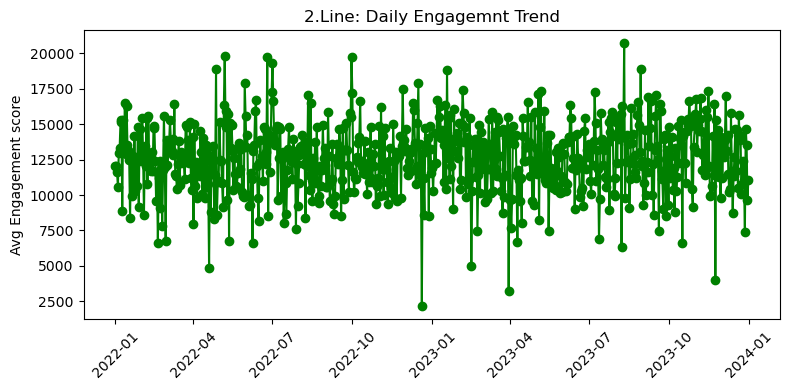

In [75]:
### 	Line: daily engagement trend


daily_eng=df.groupby(df['posted_at'].dt.date)['engagement_score'].mean() 
plt.figure(figsize=(8,4))

plt.plot(daily_eng.index,daily_eng.values,marker='o',color='green')
plt.xticks(rotation=45)


plt.ylabel('Avg Engagement score')
plt.title('2.Line: Daily Engagemnt Trend')
plt.tight_layout()
plt.show()


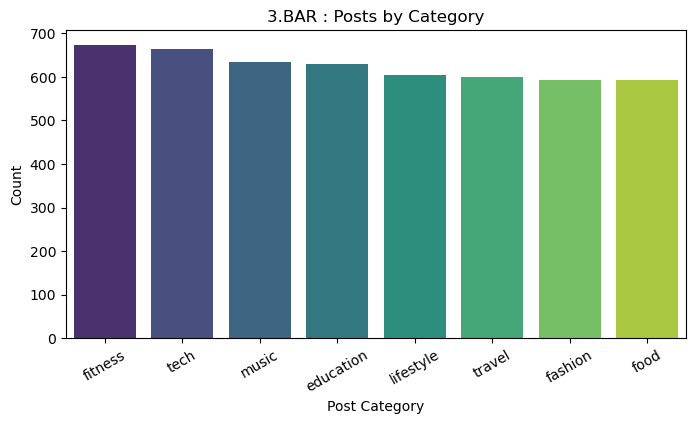

In [76]:
##### ○	Bar: posts by category

plt.figure(figsize=(8,4))
sns.countplot(data=df,x='post_category',palette='viridis',order=df['post_category'].value_counts().index)

plt.title('3.BAR : Posts by Category')
plt.xlabel('Post Category')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()
          


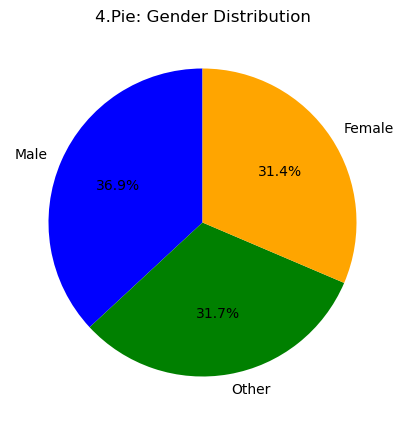

In [78]:
 ####     Pie: gender distribution

gender_counts=df['gender'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(gender_counts.values,labels=gender_counts.index,autopct='%1.1f%%',startangle=90,colors=['blue','green','orange'])
plt.title('4.Pie: Gender Distribution')

plt.show()

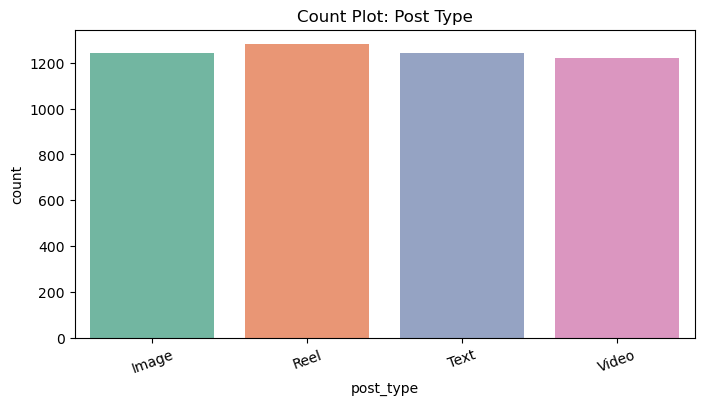

In [83]:
####  ●	Seaborn

####     Count plot: post type

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='post_type', palette='Set2')
plt.title('Count Plot: Post Type')
plt.xticks(rotation=20)

plt.show()


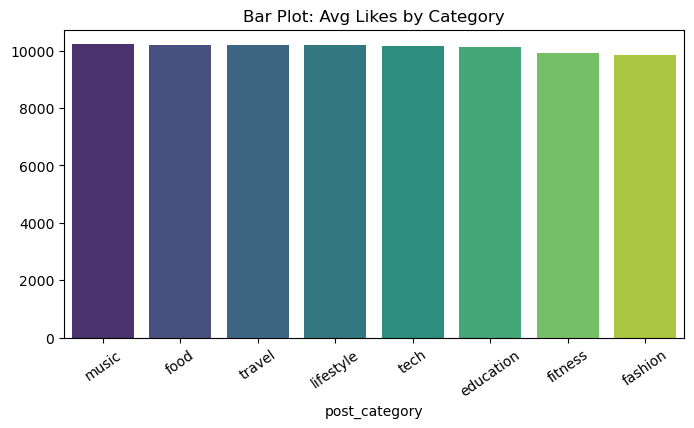

In [86]:
####    Bar plot: avg likes by category


plt.figure(figsize=(8,4))
avg_likes=df.groupby('post_category')['likes'].mean().sort_values(ascending=False)

sns.barplot(x=avg_likes.index,y=avg_likes.values,palette='viridis')

plt.xticks(rotation=35)
plt.title('Bar Plot: Avg Likes by Category')
plt.show()

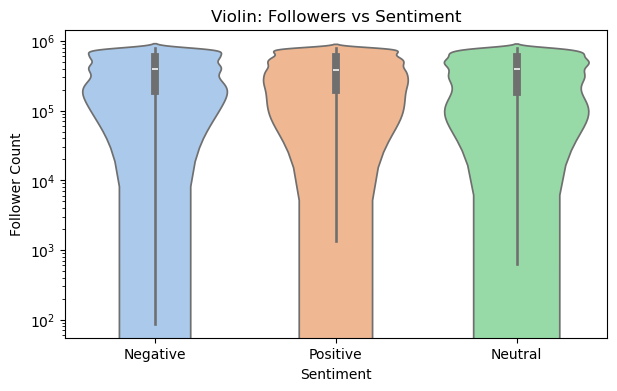

In [88]:
####   Violin: followers vs sentiment

plt.figure(figsize=(7,4))
sns.violinplot(data=df, x='sentiment', y='follower_count',palette='pastel')
plt.title('Violin: Followers vs Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.yscale('log')
plt.show()

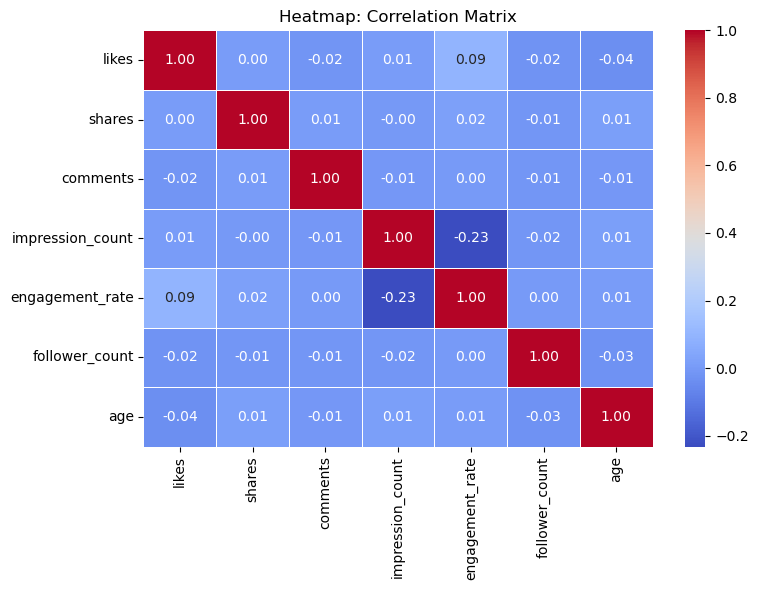

In [89]:
##### Heatmap: correlation matrix

plt.figure(figsize=(8,6))
corr=df[['likes','shares','comments','impression_count','engagement_rate','follower_count','age']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',linewidths=0.5)
plt.title('Heatmap: Correlation Matrix')
plt.tight_layout()
plt.show()

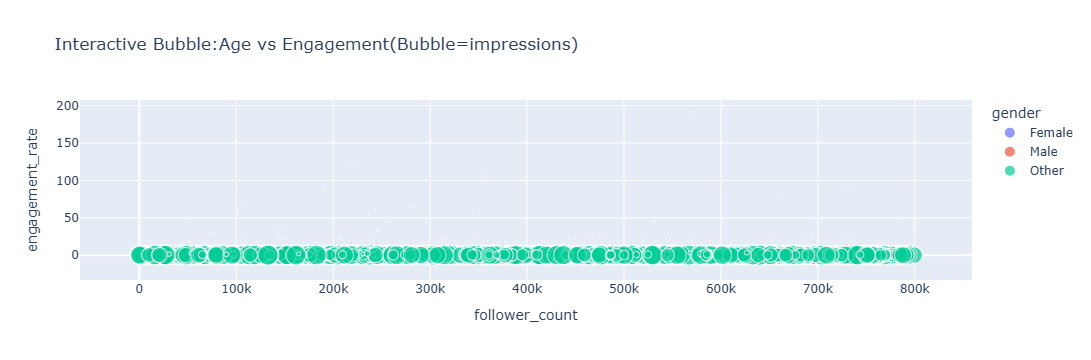

In [91]:
#### ●	Plotly (Interactive)

import plotly.express as px
fig=px.scatter(df,x='follower_count',y='engagement_rate',size='impression_count',
               color='gender',hover_name='post_category',title='Interactive Bubble:Age vs Engagement(Bubble=impressions)')
fig.show()
    

### FINAL INSIGHTS - Content Performance, User Trends, Behavioral



In [96]:
### 1. Which post types have highest engagement?

df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False)

post_type
Video    1.123815
Text     1.065721
Image    0.894868
Reel     0.783637
Name: engagement_rate, dtype: float64

In [95]:
### 2	Best-performing content category?

df.groupby('post_category')['likes'].mean().sort_values(ascending=False)

post_category
music        10220.588328
food         10209.559122
travel       10198.539232
lifestyle    10185.894040
tech         10171.560902
education    10121.592063
fitness       9909.261128
fashion       9837.364250
Name: likes, dtype: float64

In [97]:
#### 3. Which countries have highest avg engagement rate? 

df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False).head(5)

country
Brazil       1.540704
Australia    1.326949
France       1.146402
UAE          1.114099
Canada       0.918060
Name: engagement_rate, dtype: float64

In [101]:
###   4.How age affects engagement

#df.groupby('age')['engagement_rate'].mean().sort_values(ascending=False).head(5)

df.groupby(pd.cut(df['age'],bins=[13,18,25,35,50]))['engagement_rate'].mean()

age
(13, 18]    0.942812
(18, 25]    1.060874
(25, 35]    0.865316
(35, 50]    0.974741
Name: engagement_rate, dtype: float64

In [102]:
#### 5	Performance difference for verified accounts

df.groupby('is_verified')['engagement_rate'].mean()
df.groupby('is_verified')['follower_count'].mean()

is_verified
False    395112.985812
True     382549.160417
Name: follower_count, dtype: float64

In [106]:
### 6	Best time of day for impressions

df['post_hour']=df['posted_at'].dt.hour
best_hour=df.groupby('post_hour')['impression_count'].mean().sort_values(ascending=False)
print(best_hour.head())


post_hour
0    50029.706872
Name: impression_count, dtype: float64


In [108]:
### 7	Device type impact on watch time

print([c for c in df.columns if 'watch' in c.lower() or 'time' in c.lower()])

['watch_time_sec', 'sentiment']


In [114]:
## Sentiment Analysis

#### ●	Which sentiment performs best
print("=============================================================================")
# 1. Sentiment vs Engagement Rate
print(df.groupby('sentiment')['engagement_rate'].mean().sort_values(ascending=False))
print("=============================================================================")
# 2. Sentiment vs Watch Time
print(df.groupby('sentiment')['watch_time_sec'].mean().sort_values(ascending=False))
print("=============================================================================")
# 3. Sentiment vs Likes + Impressions
print(df.groupby('sentiment')[['likes','impression_count']].mean().sort_values(by='likes', ascending=False))
print("=============================================================================")


sentiment
Negative    1.039952
Neutral     0.990879
Positive    0.920577
Name: engagement_rate, dtype: float64
sentiment
Negative    4055.649269
Neutral     4029.152787
Positive    3991.107257
Name: watch_time_sec, dtype: float64
                  likes  impression_count
sentiment                                
Negative   10208.041754      50192.504175
Positive   10180.662679      50272.486842
Neutral     9918.558033      49528.164590
